In [3]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import seaborn as sns
from itertools import cycle
color_cycle = cycle(plt.rcParams['axes.prop_cycle'].by_key()['color'])
%matplotlib inline

In [4]:

# load dataset
df = pd.read_csv("C:\\Users\\priya\\Downloads\\framingham (1).csv")

In [5]:
##shape of the dataset
print(f'The dataset has {df.shape[0]} rows and {df.shape[1]} columns.') 

The dataset has 4238 rows and 16 columns.


In [6]:
#print first five rows
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4,0,0,0,0,0,0,195,106.0,70.0,26.97,80,77,0
1,0,46,2,0,0,0,0,0,0,250,121.0,81.0,28.73,95,76,0
2,1,48,1,1,20,0,0,0,0,245,127.5,80.0,25.34,75,70,0
3,0,61,3,1,30,0,0,1,0,225,150.0,95.0,28.58,65,103,1
4,0,46,3,1,23,0,0,0,0,285,130.0,84.0,23.10,85,85,0


In [7]:
#Check the info of the data set which describes null values, data type, memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4238 non-null   int64  
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4238 non-null   int64  
 5   BPMeds           4238 non-null   int64  
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4238 non-null   int64  
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4238 non-null   float64
 13  heartRate        4238 non-null   int64  
 14  glucose          4238 non-null   int64  
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(3), int64(13)
memory usage: 529.9 KB


In [8]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.429212,49.584946,1.929920,0.494101,8.941482,0.029259,0.005899,0.310524,0.025720,233.928740,132.352407,82.893464,25.686331,75.861019,74.462482,0.151958
std,0.495022,8.572160,1.053018,0.500024,11.902399,0.168552,0.076587,0.462763,0.158316,51.169478,22.038097,11.910850,4.420935,12.081533,32.869879,0.359023
min,0.000000,32.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,83.500000,48.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,205.000000,117.000000,75.000000,23.050000,68.000000,68.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,233.000000,128.000000,82.000000,25.380000,75.000000,77.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,89.875000,28.037500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


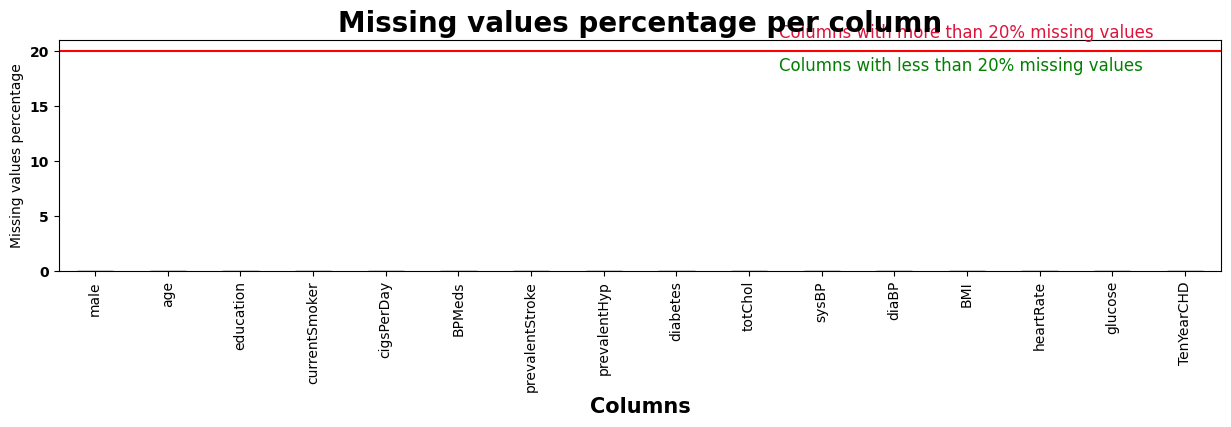

In [9]:
def msv_1(df, thresh = 20, color = 'black', edgecolor = 'black', height = 3, width = 15):
    
    plt.figure(figsize = (width, height))
    percentage = (df.isnull().mean()) * 100
    percentage.sort_values(ascending = False).plot.bar(color = color, edgecolor = edgecolor)
    plt.axhline(y = thresh, color = 'r', linestyle = '-')
    
    plt.title('Missing values percentage per column', fontsize=20, weight='bold' )
    
    plt.text(len(df.isnull().sum()/len(df))/1.7, thresh+2.5, f'Columns with more than {thresh}% missing values', fontsize=12, color='crimson',
         ha='left' ,va='top')
    plt.text(len(df.isnull().sum()/len(df))/1.7, thresh - 0.5, f'Columns with less than {thresh}% missing values', fontsize=12, color='green',
         ha='left' ,va='top')
    plt.xlabel('Columns', size=15, weight='bold')
    plt.ylabel('Missing values percentage')
    plt.yticks(weight ='bold')
    
    return plt.show()
msv_1(df, 20, color=sns.color_palette('Reds',15))

In [10]:
print(f'There are {df.isnull().any().sum()} columns in diabetes dataset with missing values.')

There are 0 columns in diabetes dataset with missing values.


<Axes: >

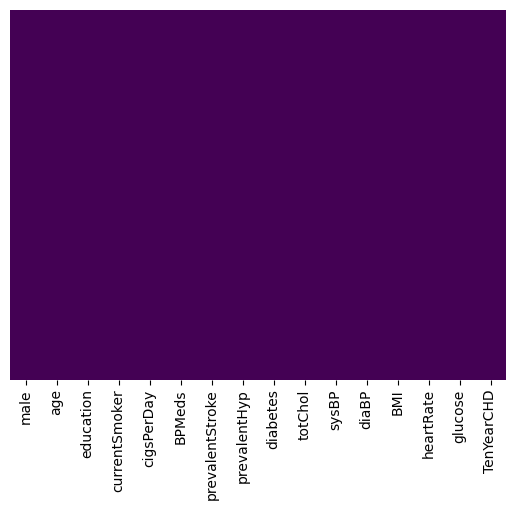

In [11]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

array([[<Axes: title={'center': 'male'}>,
        <Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'education'}>,
        <Axes: title={'center': 'currentSmoker'}>],
       [<Axes: title={'center': 'cigsPerDay'}>,
        <Axes: title={'center': 'BPMeds'}>,
        <Axes: title={'center': 'prevalentStroke'}>,
        <Axes: title={'center': 'prevalentHyp'}>],
       [<Axes: title={'center': 'diabetes'}>,
        <Axes: title={'center': 'totChol'}>,
        <Axes: title={'center': 'sysBP'}>,
        <Axes: title={'center': 'diaBP'}>],
       [<Axes: title={'center': 'BMI'}>,
        <Axes: title={'center': 'heartRate'}>,
        <Axes: title={'center': 'glucose'}>,
        <Axes: title={'center': 'TenYearCHD'}>]], dtype=object)

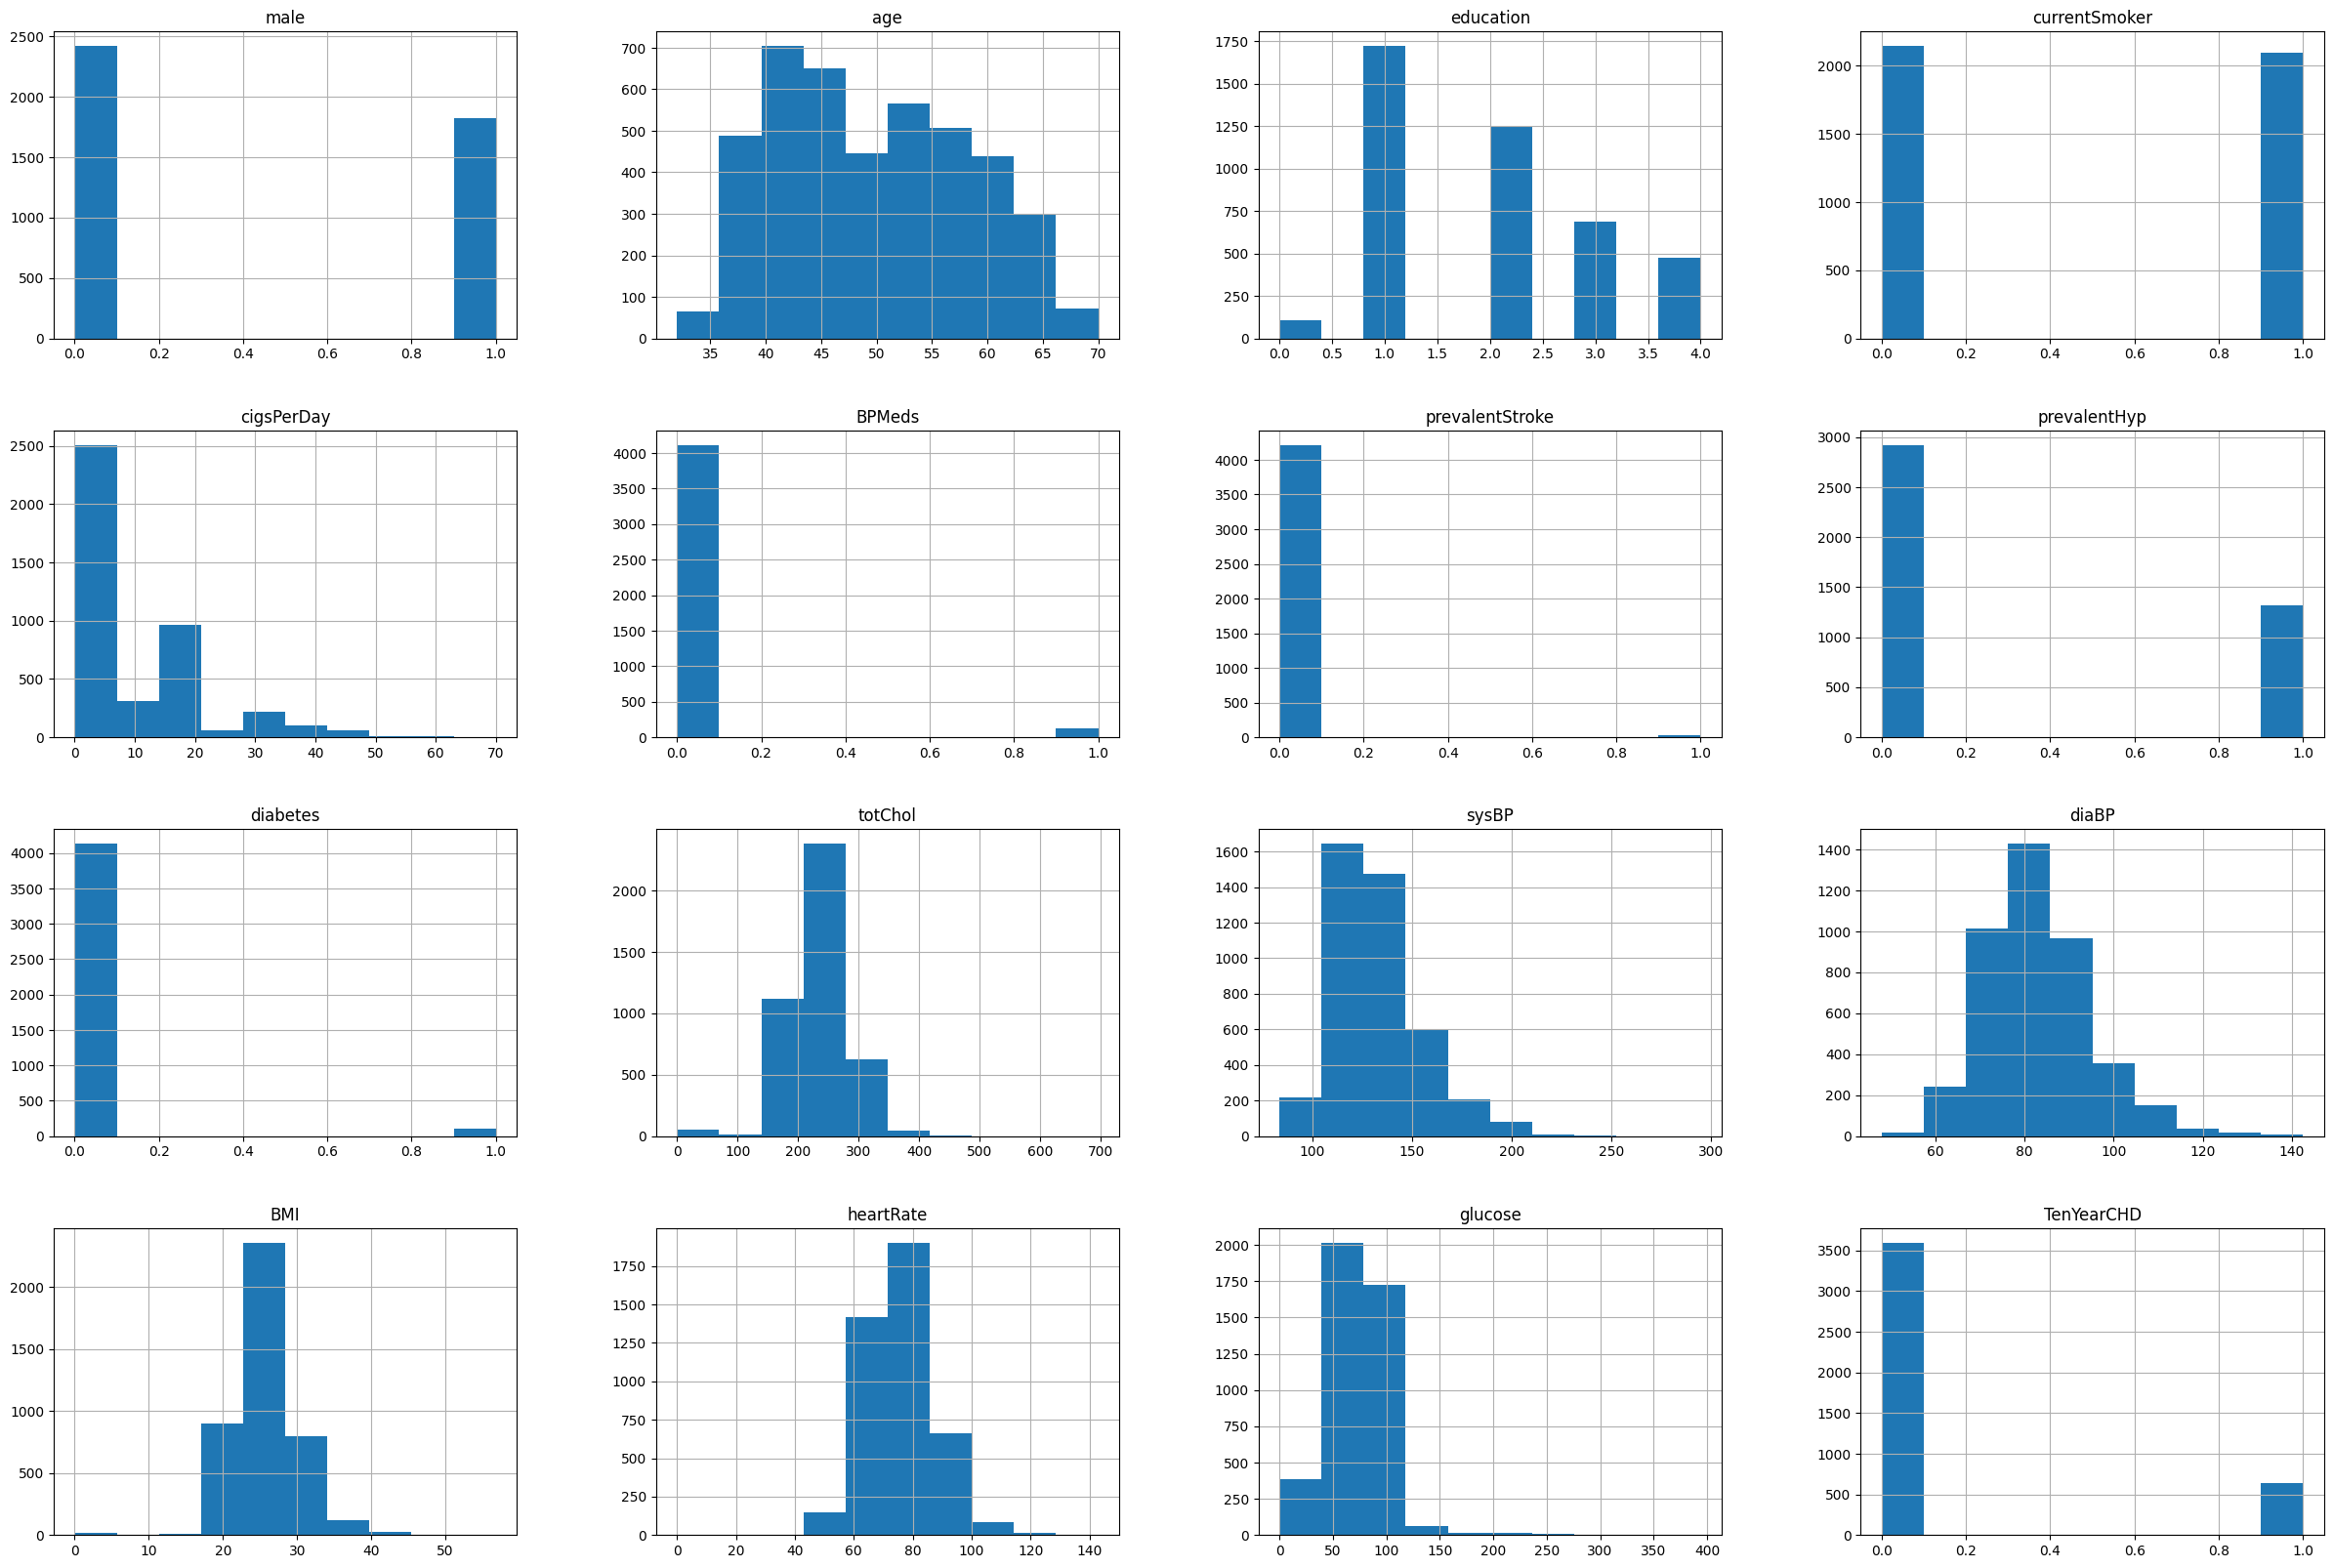

In [12]:
# Histogram 

df.hist(figsize=(30,20))

In [13]:
df_corr = df.corr().transpose()
df_corr

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
male,1.000000,-0.028979,0.009271,0.197596,0.315630,-0.051545,-0.004546,0.005313,0.015708,-0.028720,-0.035989,0.057933,0.083833,-0.117767,0.065312,0.088428
age,-0.028979,1.000000,-0.162404,-0.213748,-0.191847,0.120955,0.057655,0.307194,0.101258,0.213395,0.394302,0.206104,0.118325,-0.015252,0.096765,0.225256
education,0.009271,-0.162404,1.000000,0.020058,0.011875,-0.009721,-0.029991,-0.074963,-0.037320,-0.013041,-0.121446,-0.062326,-0.126942,-0.043082,-0.029959,-0.051109
currentSmoker,0.197596,-0.213748,0.020058,1.000000,0.760239,-0.048358,-0.032988,-0.103260,-0.044295,-0.053841,-0.130230,-0.107746,-0.147455,0.060557,-0.053267,0.019456
cigsPerDay,0.315630,-0.191847,0.011875,0.760239,1.000000,-0.044675,-0.032244,-0.065046,-0.036150,-0.035332,-0.088375,-0.056687,-0.077976,0.072393,-0.043447,0.058859
BPMeds,-0.051545,0.120955,-0.009721,-0.048358,-0.044675,1.000000,0.114609,0.258697,0.051394,0.058228,0.251503,0.192356,0.088130,0.015326,0.038666,0.086417
prevalentStroke,-0.004546,0.057655,-0.029991,-0.032988,-0.032244,0.114609,1.000000,0.074830,0.006949,0.004263,0.057009,0.045190,-0.011082,-0.017479,0.022448,0.061810
prevalentHyp,0.005313,0.307194,-0.074963,-0.103260,-0.065046,0.258697,0.074830,1.000000,0.077808,0.142479,0.696755,0.615751,0.273503,0.144327,0.068401,0.177603
diabetes,0.015708,0.101258,-0.037320,-0.044295,-0.036150,0.051394,0.006949,0.077808,1.000000,0.036702,0.111283,0.050329,0.066272,0.049006,0.443046,0.097317
totChol,-0.028720,0.213395,-0.013041,-0.053841,-0.035332,0.058228,0.004263,0.142479,0.036702,1.000000,0.173608,0.141129,0.096113,0.067856,0.133097,0.066444


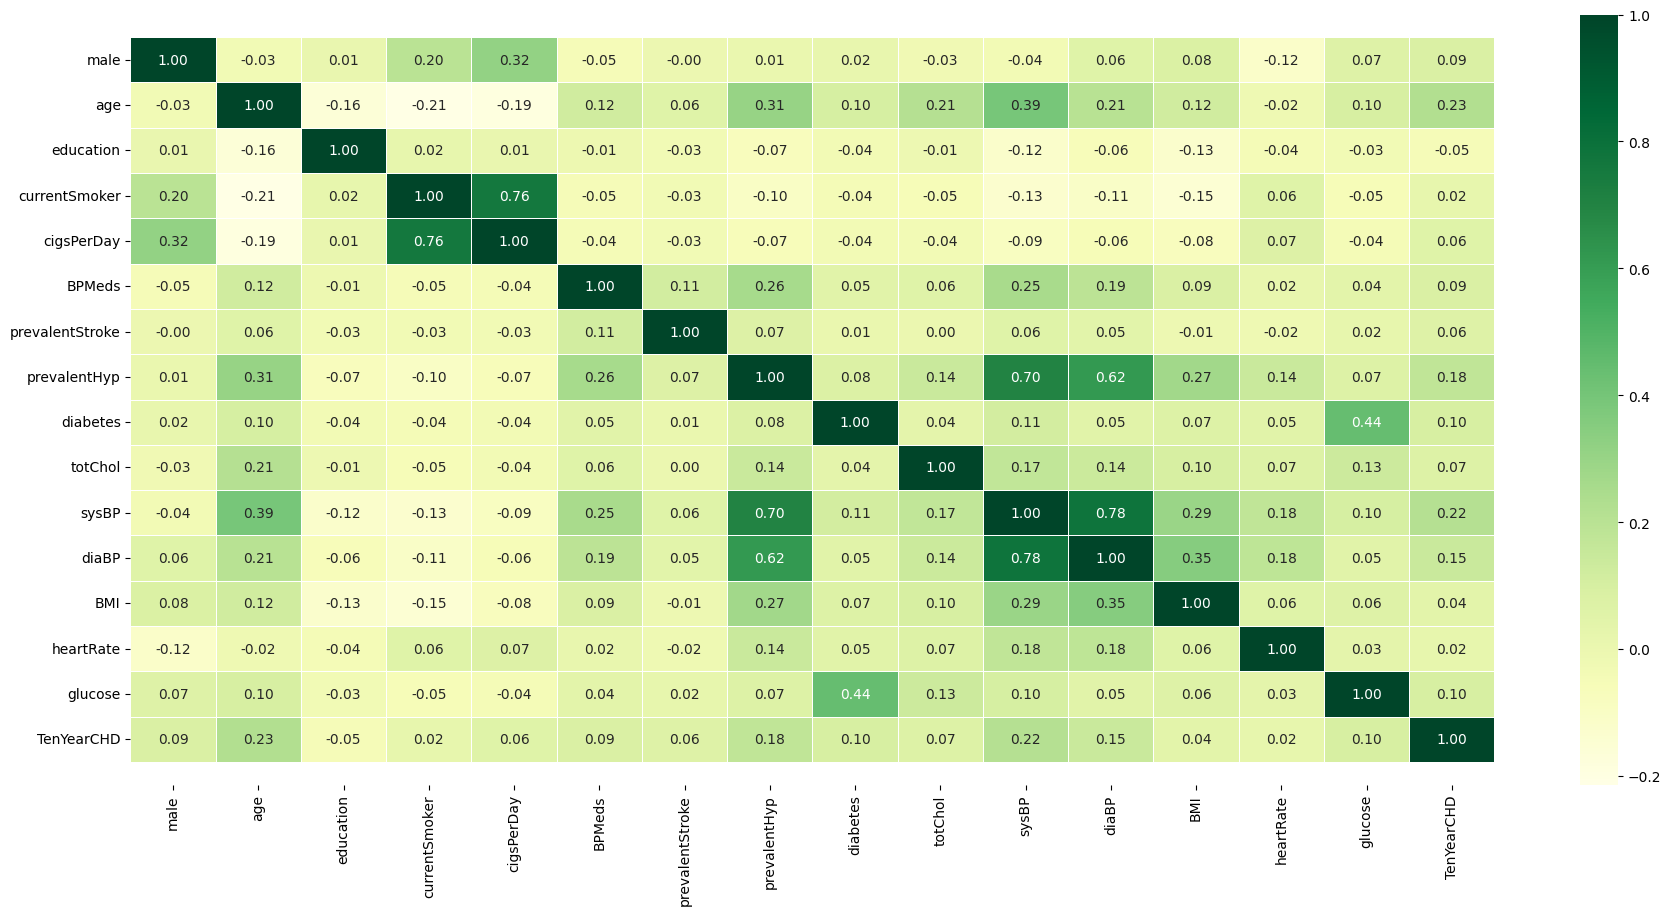

In [14]:
corr_matrix = df.corr()
fig, ax = plt.subplots(figsize=(22, 10))
ax = sns.heatmap(corr_matrix,annot=True,linewidths=0.5,fmt=".2f",cmap="YlGn");
bottom, top = ax.get_ylim()
ax.set_ylim(bottom + 0.5, top - 0.5);

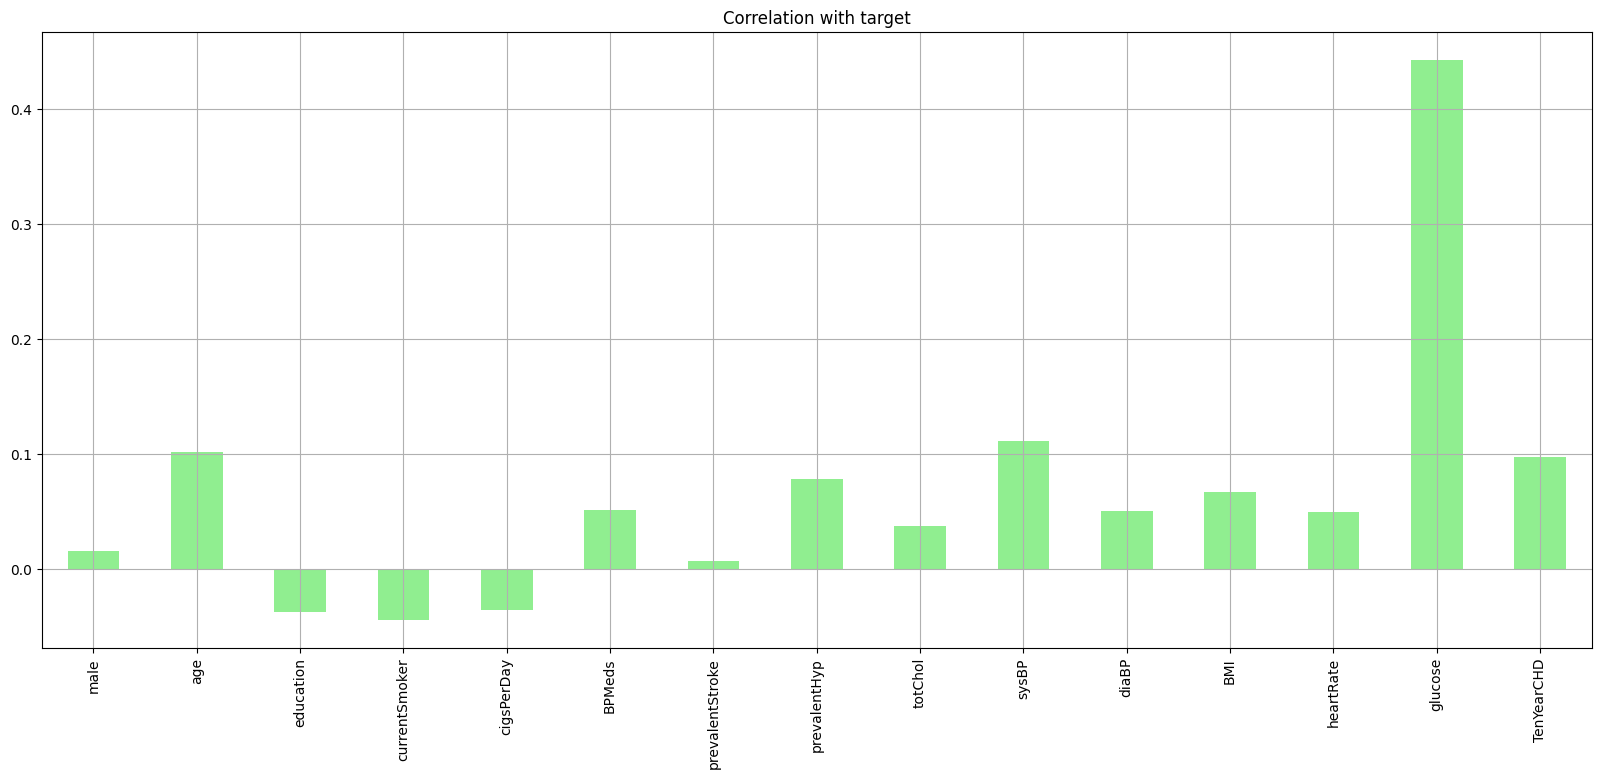

In [15]:
df.drop('diabetes', axis=1).corrwith(df.diabetes).plot(kind='bar', grid=True, figsize=(20, 8), title="Correlation with target",color="lightgreen");

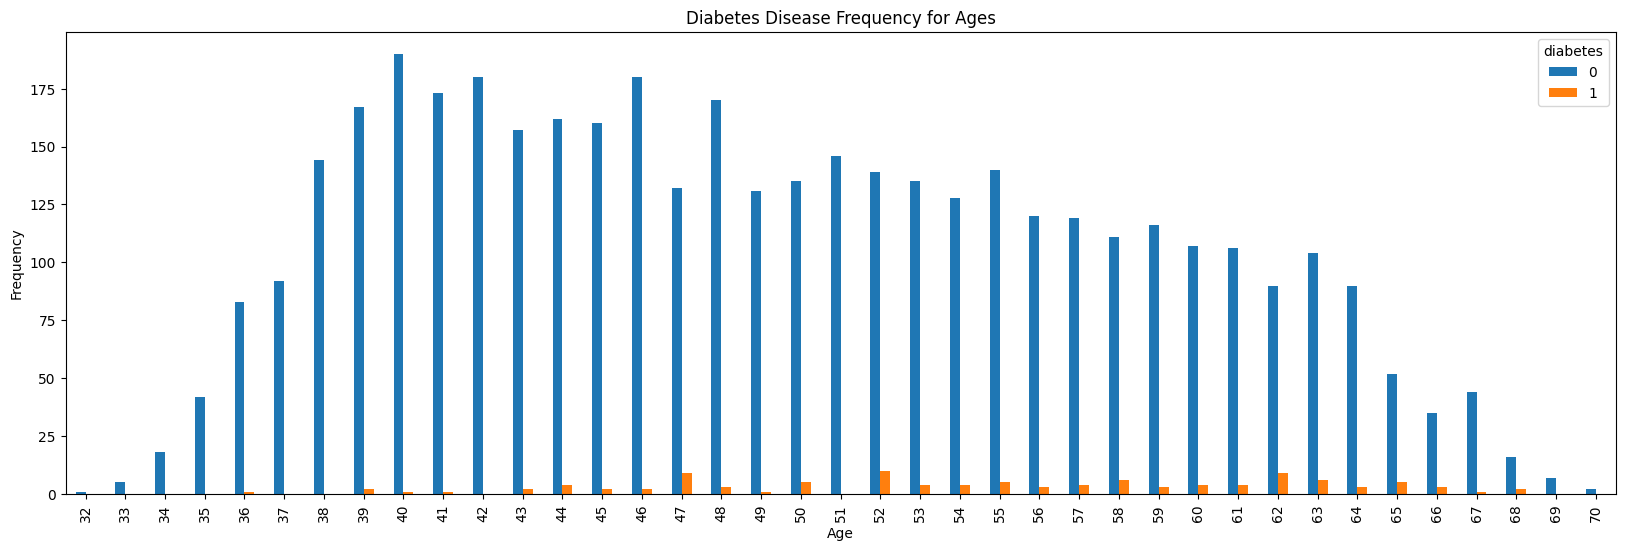

In [22]:
pd.crosstab(df.age,df.diabetes).plot(kind="bar",figsize=(20,6))
plt.title('Diabetes Disease Frequency for Ages')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

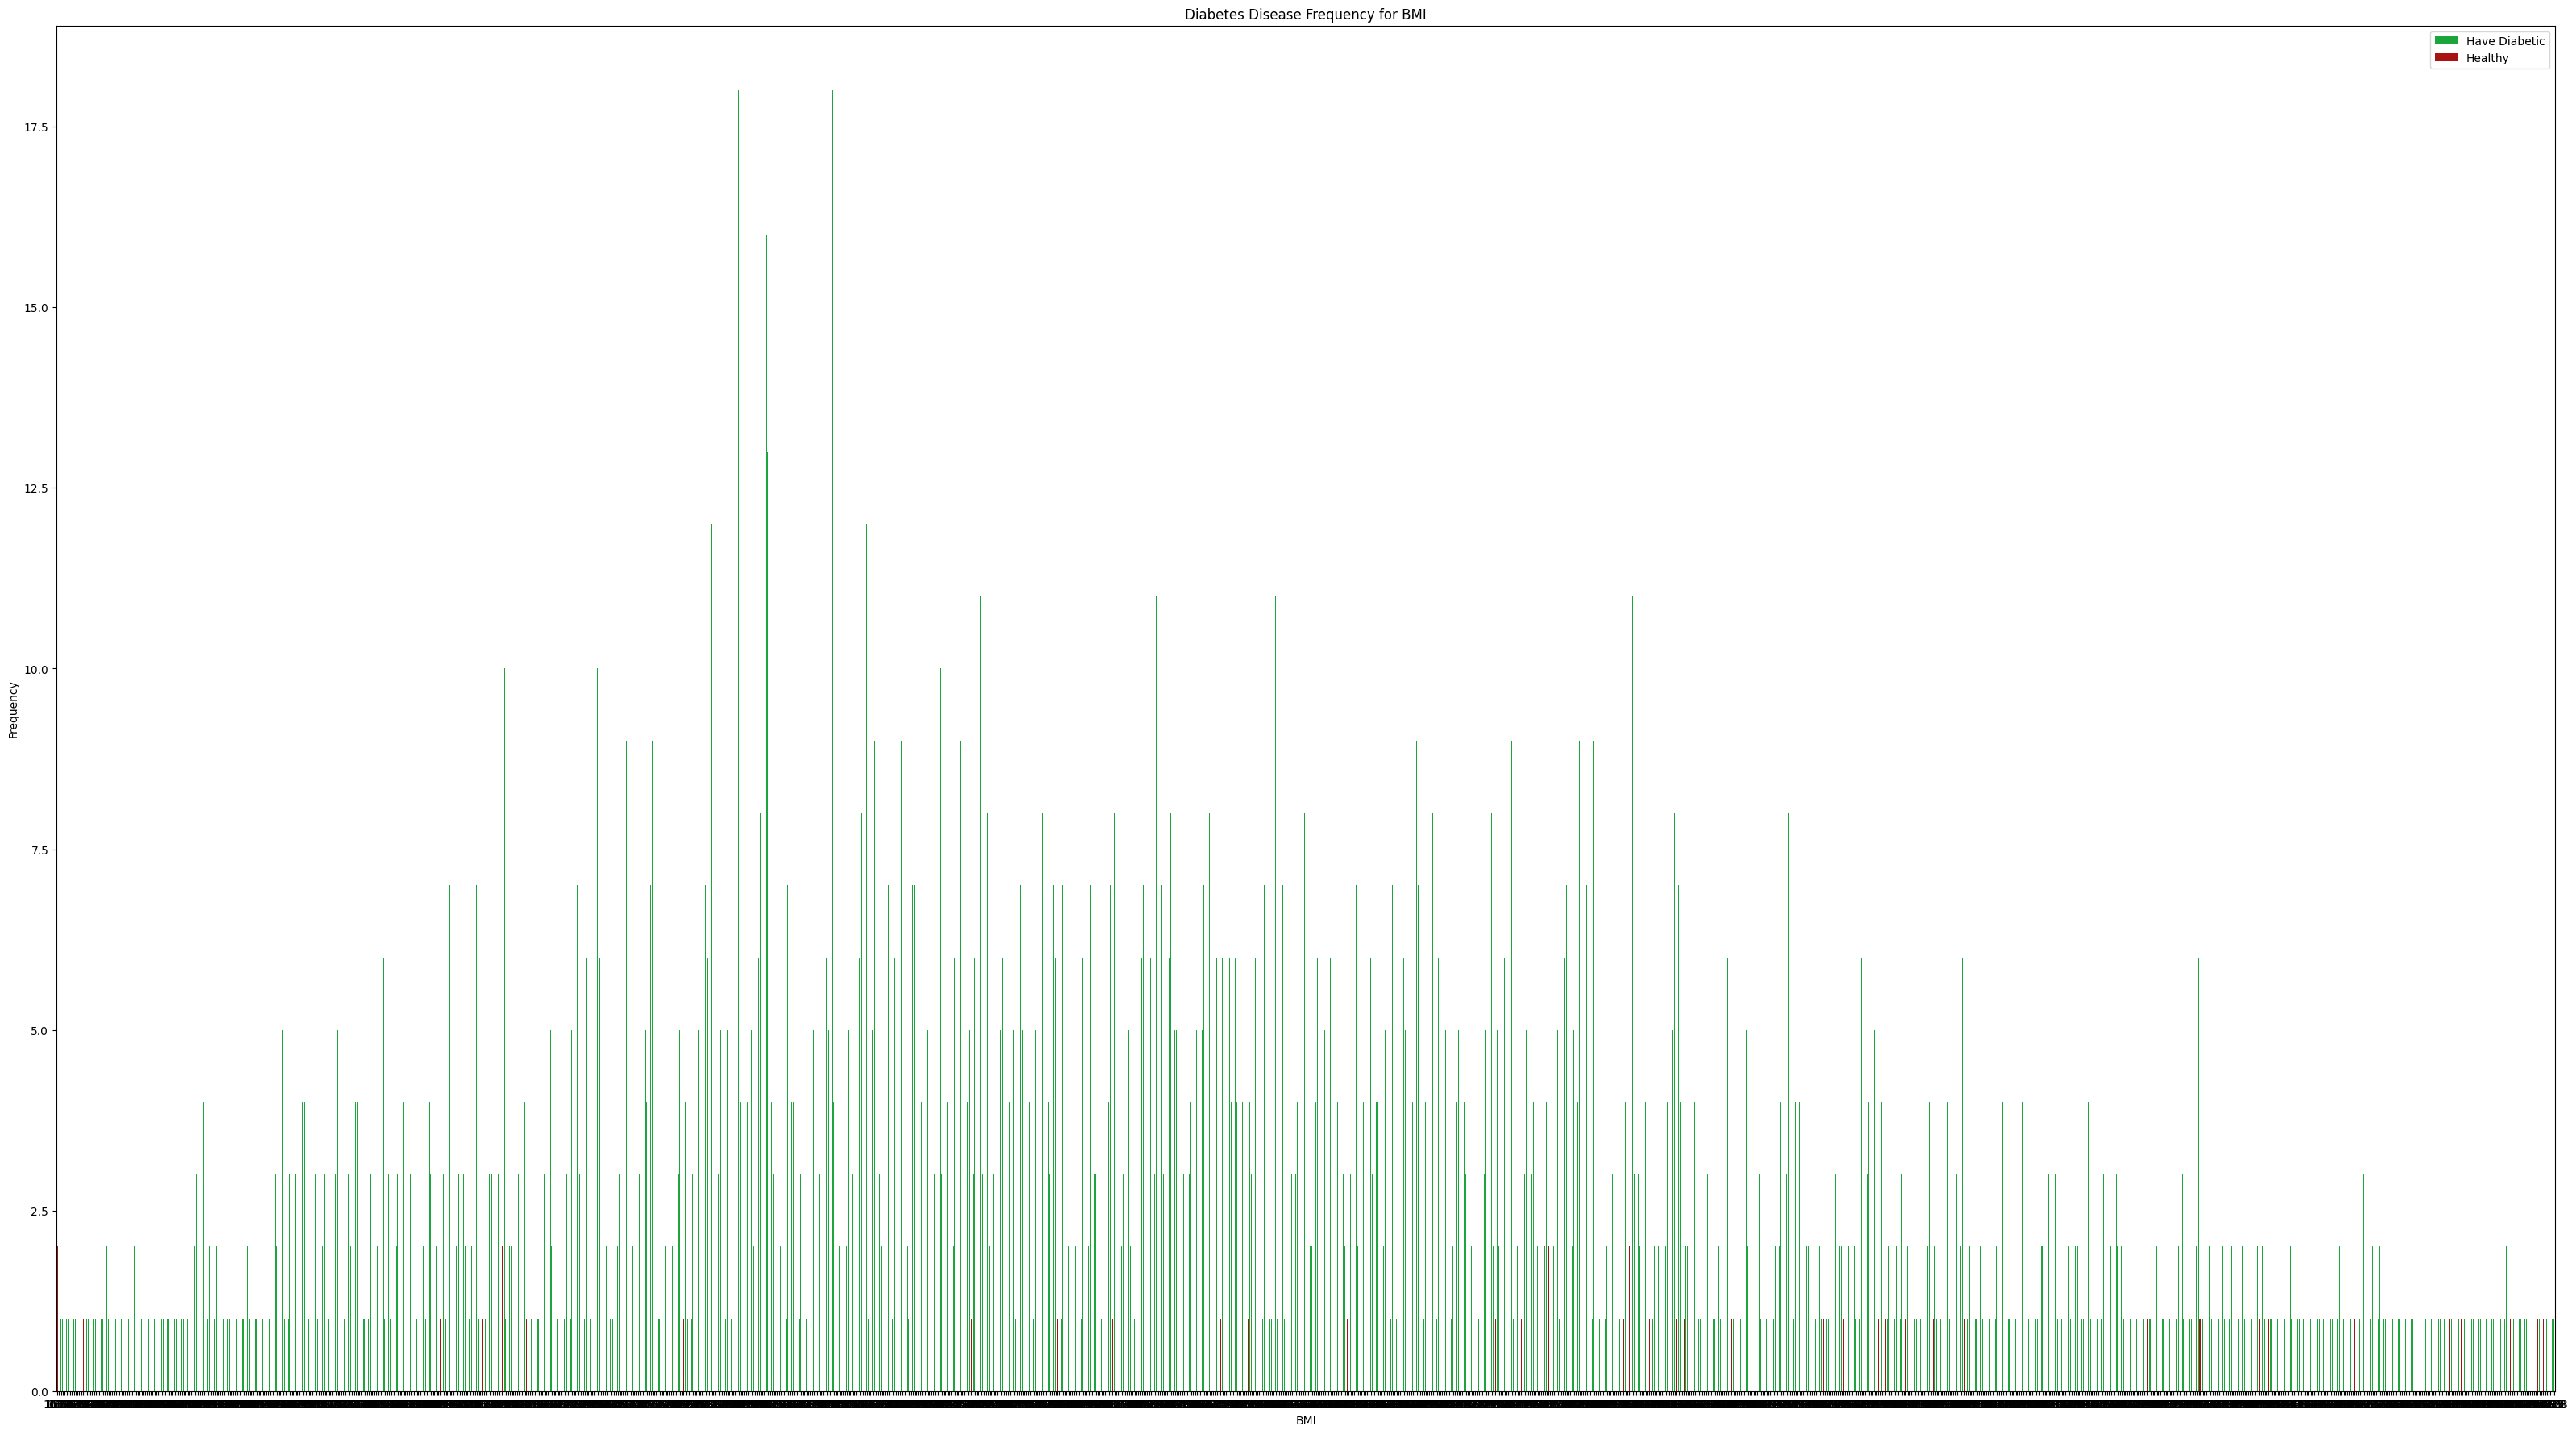

In [26]:
pd.crosstab(df.BMI,df.diabetes).plot(kind="bar",figsize=(40,22),color=['#1CA53B','#AA1111', '#FFA500' ])
plt.title('Diabetes Disease Frequency for BMI')
plt.xlabel('BMI')
plt.xticks(rotation=0)
plt.legend(["Have Diabetic", "Healthy", "Have Pre-Diabetic"])
plt.ylabel('Frequency')
plt.show()

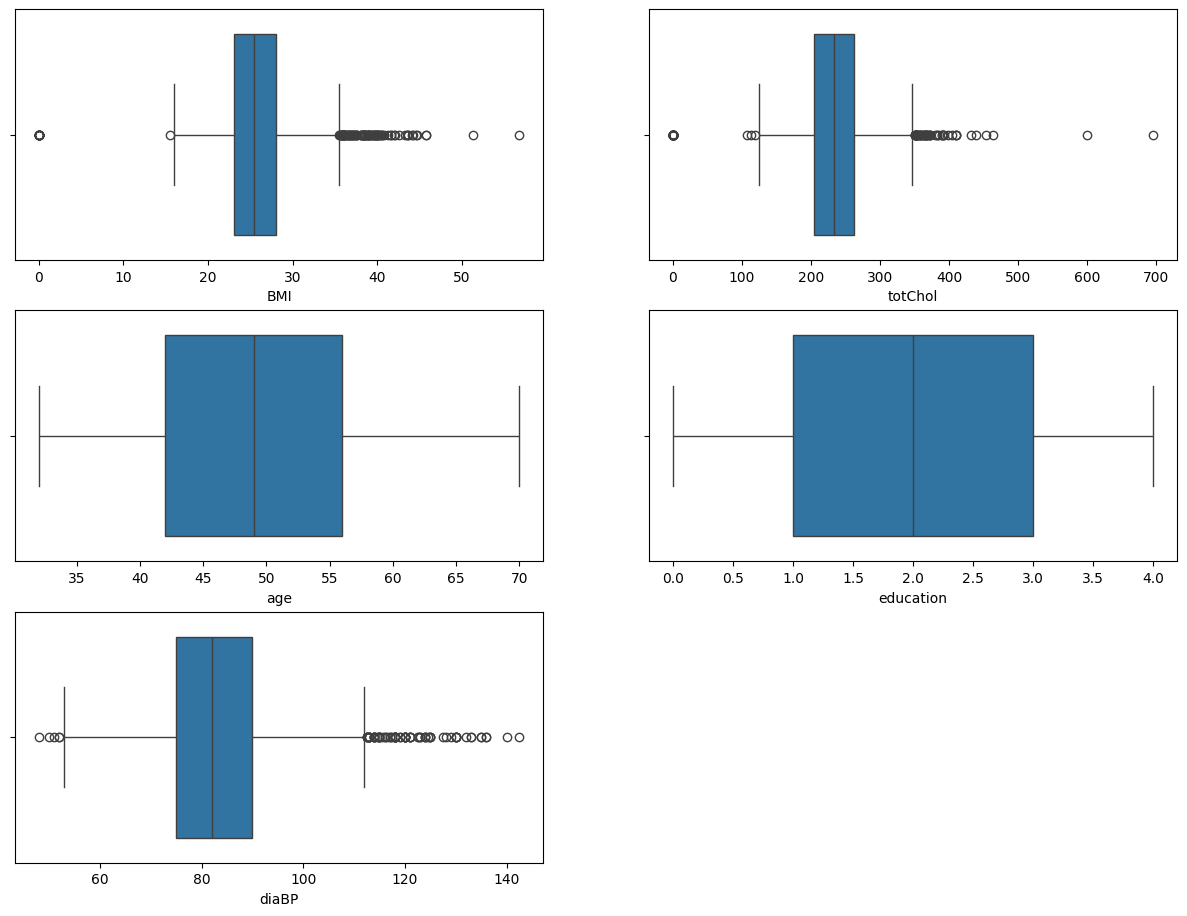

In [27]:
plt.figure(figsize = (15,15))
for i,col in enumerate(['BMI', 'totChol', 'age','education', 'diaBP']):
    plt.subplot(4,2,i+1)
    sns.boxplot(x = col, data = df)
plt.show()

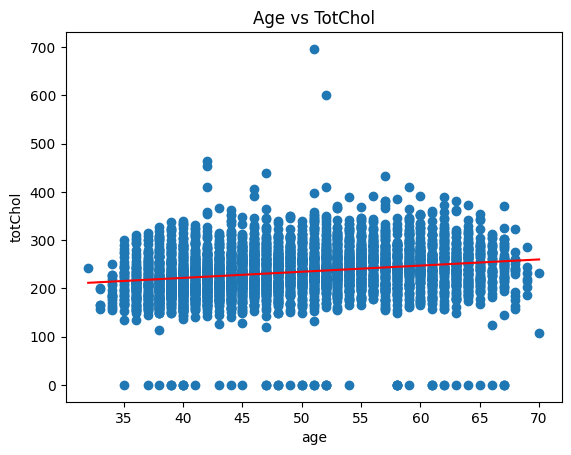

In [28]:
y = df['totChol']
x = df['age']
# plotting the data
plt.scatter(x, y)
plt.title("Age vs TotChol")
plt.xlabel("age")
plt.ylabel("totChol")
# This will fit the best line into the graph
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))
(np.unique(x)), color='red')

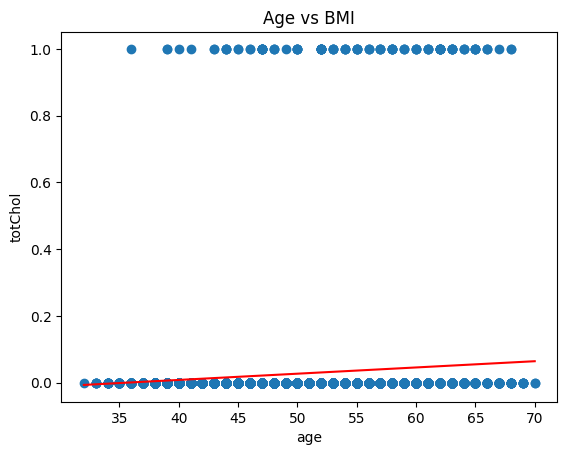

In [29]:
y = df['diabetes']
x = df['age']
# plotting the data
plt.scatter(x, y)
plt.title("Age vs Diabetes")
plt.xlabel("age")
plt.ylabel("totChol")
# This will fit the best line into the graph
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))
(np.unique(x)), color='red')

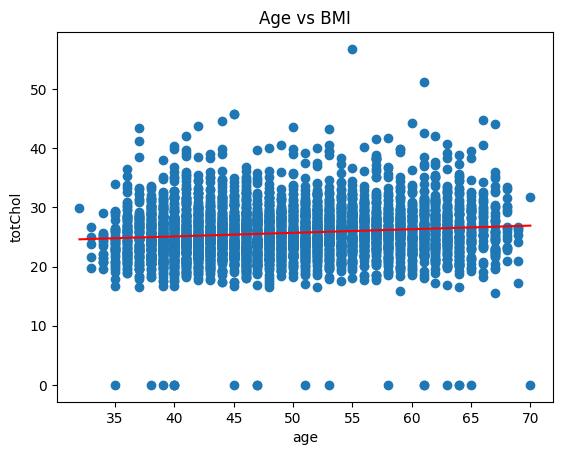

In [30]:
y = df['BMI']
x = df['age']
# plotting the data
plt.scatter(x, y)
plt.title("Age vs BMI")
plt.xlabel("age")
plt.ylabel("totChol")
# This will fit the best line into the graph
plt.plot(np.unique(x), np.poly1d(np.polyfit(x, y, 1))
(np.unique(x)), color='red')